In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (Input, Embedding, SpatialDropout1D, Conv1D, 
                                     MaxPooling1D, GlobalMaxPooling1D, LSTM, 
                                     Bidirectional, Dense, Dropout, 
                                     BatchNormalization, concatenate)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import gensim.downloader as gensim_load

# Downloads
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\heman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\heman\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
# Load the dataset
df = pd.read_csv(r"C:\MH_Sentiment_Project\Combined Data.csv")
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df.dropna(inplace=True)

# Resampling to Balance Classes (Equal weight to all emotions)
def resample_data(df):
    max_count = df['status'].value_counts().max()
    df_resampled = pd.DataFrame()
    for status in df['status'].unique():
        df_class = df[df['status'] == status]
        if len(df_class) < max_count:
            df_class_resampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
            df_resampled = pd.concat([df_resampled, df_class_resampled])
        else:
            df_resampled = pd.concat([df_resampled, df_class])
    return df_resampled

df = resample_data(df)
print("Balance distribution after resampling:\n", df['status'].value_counts())

Balance distribution after resampling:
 status
Anxiety                 16343
Normal                  16343
Depression              16343
Suicidal                16343
Stress                  16343
Bipolar                 16343
Personality disorder    16343
Name: count, dtype: int64


In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Removing special characters and lowercasing
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text).lower())
    tokens = text.split()
    # Lemmatization and Stopword removal
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['statement'] = df['statement'].apply(preprocess_text)

# Encoding Labels
X = df['statement'].values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['status'].values)
y_categorical = to_categorical(y_encoded)

# Train-Test Split (90-10)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.1, random_state=42)

# Tokenization
max_words = 50000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding='post')
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding='post')

In [20]:
import gensim.downloader as api  # Using 'api' is the standard convention to avoid naming conflicts

print("Loading Pre-trained Word2Vec (Google News 300)... This may take a minute.")
# Fix: Use api.load instead of calling the module directly
word2vec_model = api.load("word2vec-google-news-300")

embedding_dim = 300
word_index = tokenizer.word_index
num_words = min(max_words, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        if word in word2vec_model:
            embedding_matrix[i] = word2vec_model[word]
        else:
            # Initialize missing words with random vectors
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
            
print(f"Embedding Matrix ready with {num_words} words.")

Loading Pre-trained Word2Vec (Google News 300)... This may take a minute.
Embedding Matrix ready with 50000 words.


In [21]:
# 1. PURE CNN
def get_cnn():
    model = Sequential([
        Embedding(num_words, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(0.3),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(7, activation='softmax')
    ], name="CNN_Model")
    return model

# 2. PURE LSTM
def get_lstm():
    model = Sequential([
        Embedding(num_words, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False),
        SpatialDropout1D(0.3),
        LSTM(128, dropout=0.2),
        Dense(64, activation='relu'),
        Dense(7, activation='softmax')
    ], name="LSTM_Model")
    return model

# 3. CNN-LSTM (Sequential)
def get_cnn_lstm():
    model = Sequential([
        Embedding(num_words, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False),
        Conv1D(128, 5, activation='relu', padding='same'),
        MaxPooling1D(pool_size=4),
        LSTM(128),
        Dense(7, activation='softmax')
    ], name="CNN_LSTM_Model")
    return model

# 4. CNN-BiLSTM (Improved Hybrid Parallel)
def get_cnn_bilstm():
    input_text = Input(shape=(max_len,))
    emb = Embedding(num_words, embedding_dim, weights=[embedding_matrix], trainable=False)(input_text)
    x = SpatialDropout1D(0.3)(emb)
    
    # CNN Branch
    cnn = Conv1D(128, 3, padding='same', activation='relu')(x)
    cnn = GlobalMaxPooling1D()(cnn)
    
    # BiLSTM Branch
    rnn = Bidirectional(LSTM(128))(x)
    
    merged = concatenate([cnn, rnn])
    dense = Dense(128, activation='relu')(merged)
    dense = BatchNormalization()(dense)
    dense = Dropout(0.5)(dense)
    output = Dense(7, activation='softmax')(dense)
    return Model(inputs=input_text, outputs=output, name="CNN_BiLSTM_Model")

In [22]:
# Select model (e.g., get_cnn_bilstm() for best results)
model = get_cnn_bilstm() 
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

print(f"Training {model.name}...")
history = model.fit(
    X_train_padded, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=callbacks
)

# Save in both requested formats
model.save("sentiment analysis .keras")
model.save("mental_health_model.h5")
print("Models saved successfully.")

Training CNN_BiLSTM_Model...
Epoch 1/15


724/724 [==============================] - 154s 205ms/step - loss: 0.9801 - accuracy: 0.6418 - val_loss: 0.5458 - val_accuracy: 0.8037 - lr: 0.0010
Epoch 2/15
724/724 [==============================] - 158s 218ms/step - loss: 0.5828 - accuracy: 0.7891 - val_loss: 0.3763 - val_accuracy: 0.8643 - lr: 0.0010
Epoch 3/15
724/724 [==============================] - 157s 217ms/step - loss: 0.4463 - accuracy: 0.8368 - val_loss: 0.3189 - val_accuracy: 0.8871 - lr: 0.0010
Epoch 4/15
724/724 [==============================] - 250s 346ms/step - loss: 0.3746 - accuracy: 0.8622 - val_loss: 0.2757 - val_accuracy: 0.8946 - lr: 0.0010
Epoch 5/15
724/724 [==============================] - 258s 357ms/step - loss: 0.3296 - accuracy: 0.8782 - val_loss: 0.2647 - val_accuracy: 0.9015 - lr: 0.0010
Epoch 6/15
724/724 [==============================] - 246s 340ms/step - loss: 0.2973 - accuracy: 0.8901 - val_loss: 0.2336 - val_accuracy: 0.9161 - lr: 0.0010
Epoch 7/15
724/

c:\MH_Sentiment_Project\mh_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


358/358 [==============================] - 13s 33ms/step

--- Classification Report ---
                      precision    recall  f1-score   support

             Anxiety       0.98      0.99      0.99      1690
             Bipolar       0.99      1.00      0.99      1550
          Depression       0.91      0.75      0.82      1716
              Normal       0.96      0.92      0.94      1633
Personality disorder       0.99      1.00      1.00      1580
              Stress       0.96      1.00      0.98      1610
            Suicidal       0.80      0.92      0.85      1662

            accuracy                           0.94     11441
           macro avg       0.94      0.94      0.94     11441
        weighted avg       0.94      0.94      0.94     11441



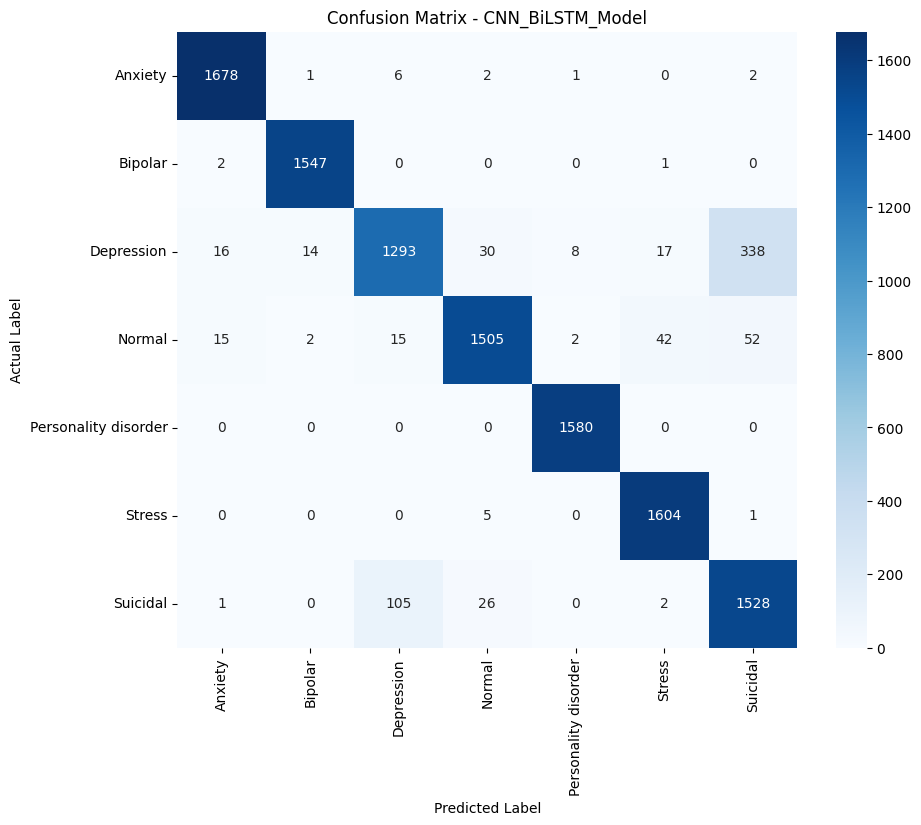

In [23]:
# Metrics Calculation
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Plot Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {model.name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [24]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import pandas as pd

# 1. Generate Predictions
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Calculate Metrics per Class
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=range(len(label_encoder.classes_)))

# 3. Create Performance Table
performance_df = pd.DataFrame({
    'Emotion': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

# Add Overall Accuracy Row
overall_acc = accuracy_score(y_true, y_pred)
print(f"\n--- OVERALL TEST ACCURACY: {overall_acc*100:.2f}% ---")
print("\n--- PERFORMANCE TABLE BY EMOTION ---")
print(performance_df.to_string(index=False))

# 4. Standard Classification Report
print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

358/358 [==============================] - 12s 33ms/step

--- OVERALL TEST ACCURACY: 93.83% ---

--- PERFORMANCE TABLE BY EMOTION ---
             Emotion  Precision   Recall  F1-Score  Support
             Anxiety   0.980140 0.992899  0.986479     1690
             Bipolar   0.989130 0.998065  0.993577     1550
          Depression   0.911205 0.753497  0.824880     1716
              Normal   0.959821 0.921617  0.940331     1633
Personality disorder   0.993086 1.000000  0.996531     1580
              Stress   0.962785 0.996273  0.979243     1610
            Suicidal   0.795419 0.919374  0.852917     1662

--- DETAILED CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

             Anxiety       0.98      0.99      0.99      1690
             Bipolar       0.99      1.00      0.99      1550
          Depression       0.91      0.75      0.82      1716
              Normal       0.96      0.92      0.94      1633
Personality disorder       0.99    

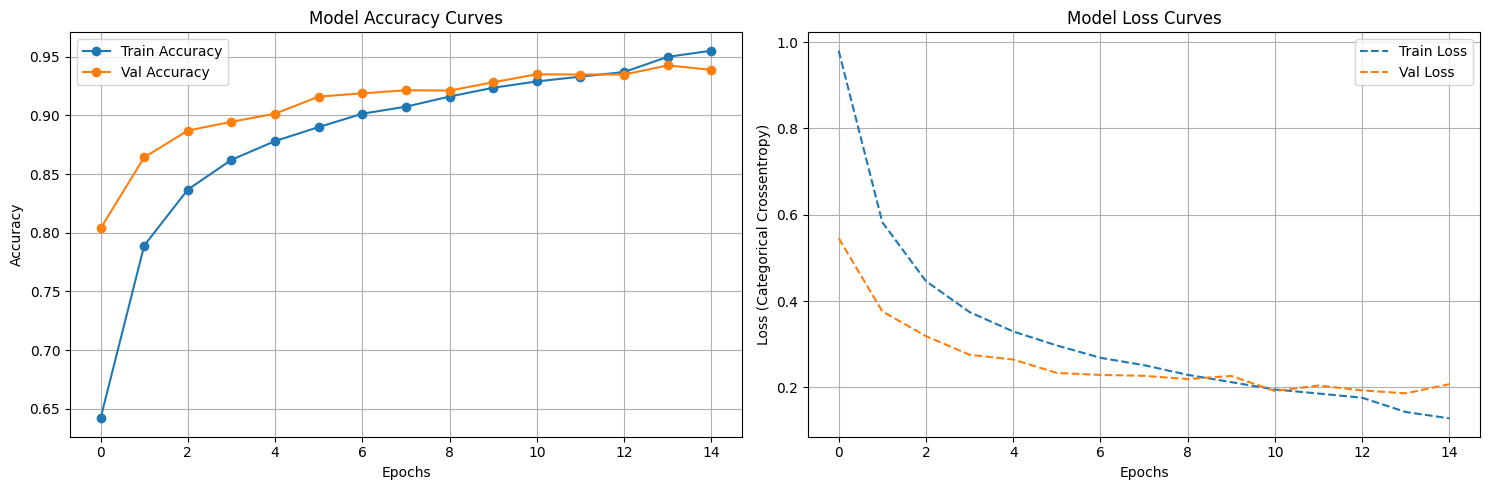

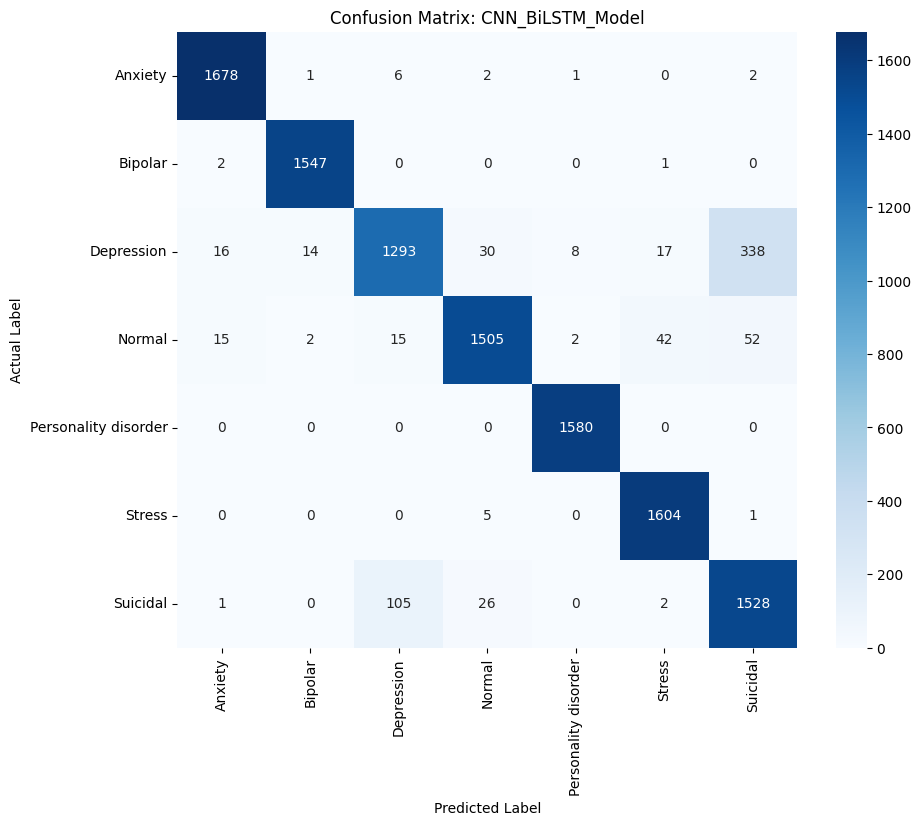

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot Training & Validation History (Loss and Accuracy)
plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Model Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix: {model.name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

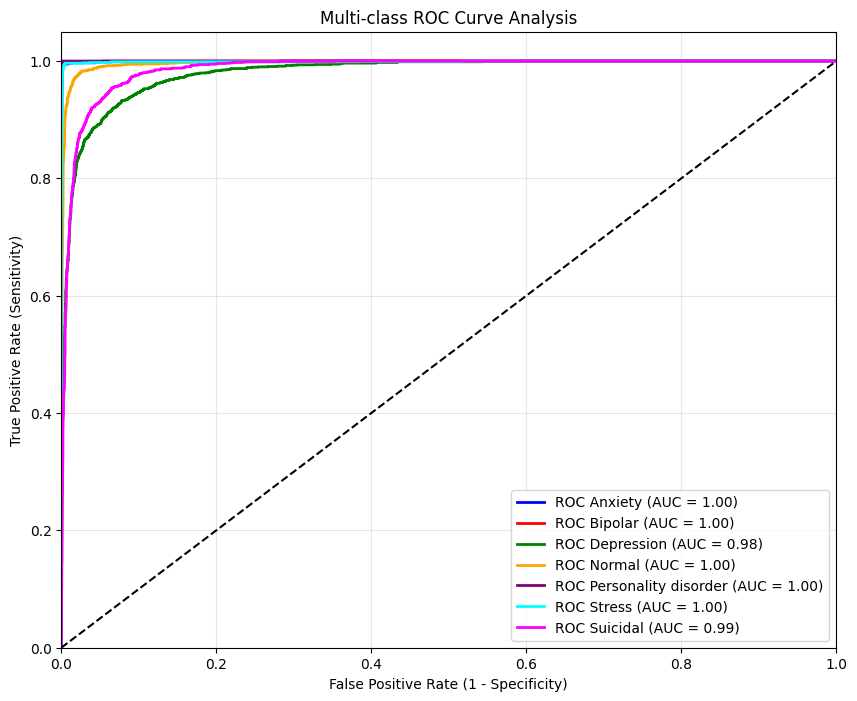


[FINALIZE]
All metrics generated.
Model saved as: sentiment analysis.keras
Model saved as: mental_health_model.h5


In [26]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# 1. Calculate ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(label_encoder.classes_)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 2. Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multi-class ROC Curve Analysis')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 3. Final Model Save Confirmation
print("\n[FINALIZE]")
print("All metrics generated.")
print("Model saved as: sentiment analysis.keras")
print("Model saved as: mental_health_model.h5")

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

# --- SETTINGS ---
MODEL_PATH = "sentiment analysis.keras"
MAX_LEN = 100

def load_prediction_tools():
    """Load the model and required preprocessing tools"""
    try:
        # Load the trained model
        model = tf.keras.models.load_model(r"C:\MH_Sentiment_Project\code\sentiment analysis .keras")
        print(f"Successfully loaded: {MODEL_PATH}")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

# Initialize the predictor
predictor_model = load_prediction_tools()

def get_intensity(confidence):
    """Calculate the intensity based on model confidence"""
    if confidence > 0.90: return "CRITICAL / HIGH"
    elif confidence > 0.75: return "MODERATE"
    else: return "MILD / STABLE"

def predict_single_post(text):
    """Analyze a single string of text"""
    if predictor_model is None: return
    
    # Preprocess (using the function from Cell 3)
    clean = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=MAX_LEN)
    
    # Predict
    probs = predictor_model.predict(padded, verbose=0)[0]
    idx = np.argmax(probs)
    emotion = label_encoder.classes_[idx]
    conf = probs[idx]
    
    return {
        "text": text,
        "emotion": emotion,
        "intensity": get_intensity(conf),
        "confidence": f"{conf*100:.1f}%"
    }

def analyze_batch_file(file_path, text_column):
    """Load a CSV file and analyze a specific column of posts"""
    print(f"Reading file: {file_path}...")
    data = pd.read_csv(file_path)
    
    results = []
    print("Processing posts...")
    
    for post in data[text_column].astype(str):
        res = predict_single_post(post)
        results.append(res)
    
    # Create results dataframe
    results_df = pd.DataFrame(results)
    output_name = "mental_health_analysis_results.csv"
    results_df.to_csv(output_name, index=False)
    
    print(f"\nAnalysis Complete! Results saved to: {output_name}")
    print(results_df.head())

# --- EXAMPLES OF USE ---

# Example 1: Single Prediction
print("\n[SINGLE POST TEST]")
result = predict_single_post("I feel depressed and anxious all the time.")
print(f"Result: {result}")






Successfully loaded: sentiment analysis.keras

[SINGLE POST TEST]


NameError: name 'preprocess_text' is not defined